In [1]:
import pandas as pd

In [11]:
df=pd.read_csv("C:\\Users\\saura\\Desktop\\HA Data1.csv")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51205 entries, 0 to 51204
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   race                  51205 non-null  object 
 1   gender                51205 non-null  object 
 2   age                   51205 non-null  object 
 3   weight                51205 non-null  object 
 4   time_in_hospital      51205 non-null  int64  
 5   num_lab_procedures    51205 non-null  int64  
 6   num_procedures        51205 non-null  int64  
 7   num_medications       51205 non-null  int64  
 8   number_outpatient     51205 non-null  int64  
 9   number_emergency      51205 non-null  int64  
 10  number_inpatient      51205 non-null  int64  
 11  number_diagnoses      51205 non-null  int64  
 12  change                51205 non-null  object 
 13  diabetesMed           51205 non-null  object 
 14  readmitted            51205 non-null  int64  
 15  Gender Encoded     

In [15]:
df = df.drop(columns=['Unnamed: 32', 'Unnamed: 33'])

In [17]:
df.isnull().sum()

race                    0
gender                  0
age                     0
weight                  0
time_in_hospital        0
num_lab_procedures      0
num_procedures          0
num_medications         0
number_outpatient       0
number_emergency        0
number_inpatient        0
number_diagnoses        0
change                  0
diabetesMed             0
readmitted              0
Gender Encoded          1
Change Encoded          0
race_Caucasian          0
race_AfricanAmerican    0
race_Asian              0
race_Hispanic           0
race_Other              0
age_0_10                0
age_10_20               0
age_20_30               0
age_30_40               0
age_40_50               0
age_50_60               0
age_60_70               0
age_70_80               0
age_80_90               0
age_90_100              0
dtype: int64

In [21]:
df['Gender Encoded'] = df['Gender Encoded'].fillna(
    df['Gender Encoded'].mode()[0]
)

In [23]:
df.isnull().sum().sum()

0

In [25]:
y = df['readmitted']

In [29]:
X = df[
    [
        'time_in_hospital',
        'num_lab_procedures',
        'num_procedures',
        'num_medications',
        'number_outpatient',
        'number_emergency',
        'number_inpatient',
        'number_diagnoses',
        'Gender Encoded',
        'Change Encoded',
        'race_Caucasian',
        'race_AfricanAmerican',
        'race_Asian',
        'race_Hispanic',
        'race_Other',
        'age_0_10',
        'age_10_20',
        'age_20_30',
        'age_30_40',
        'age_40_50',
        'age_50_60',
        'age_60_70',
        'age_70_80',
        'age_80_90',
        'age_90_100'
    ]
]

In [31]:
X.shape, y.shape

((51205, 25), (51205,))

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40964, 25), (10241, 25), (40964,), (10241,))

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [39]:
y_pred = model.predict(X_test)

In [41]:
y_prob = model.predict_proba(X_test)[:, 1]

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.60687432867884
Precision: 0.6338368580060423
Recall   : 0.42711726384364823
F1 Score : 0.5103381172464121


[[4117 1212]
 [2814 2098]]


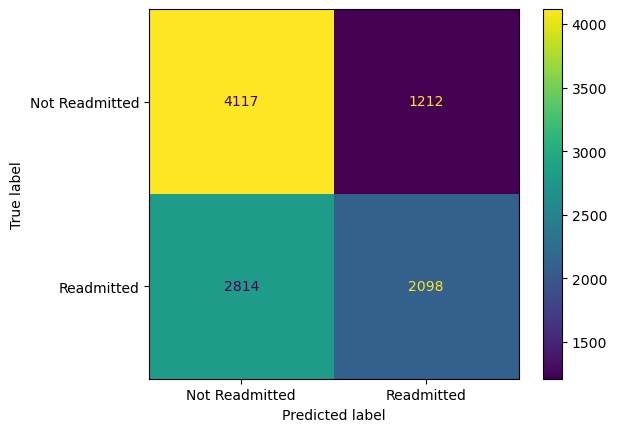

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.show()

In [49]:
features = [
    'number_inpatient',
    'number_outpatient',
    'number_emergency',
    'readmitted'
]

In [51]:
features = [
    'number_inpatient',
    'number_outpatient',
    'number_emergency'
]

X_cluster = df[features]

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

In [55]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X_scaled)

In [57]:
cluster_profile = df.groupby('cluster')[
    ['number_inpatient',
     'number_outpatient',
     'number_emergency',
     'readmitted']
].mean()

cluster_profile

,number_inpatient,number_outpatient,number_emergency,readmitted
cluster,,,,
0,0.340811,0.151344,0.093200,0.448305
1,3.670396,0.450731,1.326807,0.739458
2,0.743299,4.753748,0.292594,0.562017


In [59]:
race_readmission = df.groupby('race')['readmitted'].agg(
    readmission_rate='mean',
    patient_count='count'
)

race_readmission['readmission_rate'] = (
    race_readmission['readmission_rate'] * 100
).round(2)

race_readmission.sort_values(
    'readmission_rate',
    ascending=False
)

,readmission_rate,patient_count
race,,
Caucasian,49.12,38242
AfricanAmerican,46.88,9529
Other,42.24,850
Hispanic,41.55,1035
Asian,36.46,288
?,32.67,1261


In [61]:
current_rate = 0.7395
reduction = 0.10

new_rate = current_rate * (1 - reduction)

print("Current:", current_rate * 100)
print("Estimated:", new_rate * 100)

Current: 73.95
Estimated: 66.555
